# The Helmholtz Decomposition, Done Exactly

Any sufficiently well-behaved vector field $\mathbf F$ splits uniquely into
$$\mathbf F=\mathbf F_{\text{irrotational}}+\mathbf F_{\text{solenoidal}},
\qquad \nabla\times\mathbf F_{\text{irrotational}}=0,\qquad
\nabla\cdot\mathbf F_{\text{solenoidal}}=0.$$

`dgs.irrotational_solenoidal_polyglot` built the two SPECIAL-CASE fields
Griffiths reaches for -- one that's already purely irrotational (a point
charge's field direction), one that's already purely solenoidal (an
infinite wire's field direction). This notebook starts from a GENERIC
synthetic field with neither property and performs the actual split.

For a periodic, band-limited field the split has an exact closed form in
Fourier space: project each Fourier mode $\hat{\mathbf F}(\mathbf k)$ onto
$\mathbf k$ (longitudinal -- automatically curl-free) and onto the plane
perpendicular to $\mathbf k$ (transverse -- automatically
divergence-free). No finite-difference truncation error, the same reason
this repo's dispersion kernel is applied via FFT rather than approximated.
Cross-checked by an independent `torch.fft` implementation of the same
algorithm. Engine: `dgs/helmholtz_decomposition.py`.


In [1]:
%matplotlib inline
import sys, pathlib
sys.path.insert(0, str(pathlib.Path('..').resolve()))

import numpy as np
import matplotlib.pyplot as plt

from dgs import helmholtz_decomposition as hd

print('Setup complete.')


Setup complete.


## 1. A Generic Field: Real Curl AND Real Divergence

`synthetic_test_field` sums a handful of low-order Fourier modes into a
smooth periodic field -- generic enough to have BOTH nonzero curl and
nonzero divergence at typical points, unlike either of
`dgs.irrotational_solenoidal_polyglot`'s two special-case fields.


In [2]:
N = 24
F = hd.synthetic_test_field(N=N, n_modes=5, seed=0)
div_F = hd.spectral_divergence(F)
curl_F = hd.spectral_curl(F)
print(f'field shape: {F.shape}')
print(f'max|div(F)|  = {np.max(np.abs(div_F)):.4f}   (genuinely nonzero)')
print(f'max|curl(F)| = {np.max(np.abs(curl_F)):.4f}   (genuinely nonzero)')


field shape: (24, 24, 24, 3)
max|div(F)|  = 14.2898   (genuinely nonzero)
max|curl(F)| = 17.1833   (genuinely nonzero)


## 2. Spectral Derivatives Are Exact Here

A quick sanity check on `spectral_divergence`/`spectral_curl` themselves,
against a field with a known closed-form derivative: $F=(\cos(kx),0,0)$
has $\nabla\cdot F=-k\sin(kx)$ exactly.


In [3]:
L = 2*np.pi
x = np.linspace(0, L, N, endpoint=False)
X, Y, Z = np.meshgrid(x, x, x, indexing='ij')
k = 2
F_known = np.zeros((N, N, N, 3))
F_known[..., 0] = np.cos(k*X)

div_known = hd.spectral_divergence(F_known, L)
expected = -k*np.sin(k*X)
print(f'max|spectral div - analytic div| = {np.max(np.abs(div_known - expected)):.3e}')


max|spectral div - analytic div| = 6.661e-15


## 3. The Decomposition

`helmholtz_decompose` returns the irrotational (longitudinal) and
solenoidal (transverse) parts. Three checks: they sum back to the
original field, the irrotational part's curl is ~0, the solenoidal part's
divergence is ~0.


In [4]:
parts = hd.helmholtz_decompose(F)
F_irrot, F_sol = parts['F_irrotational'], parts['F_solenoidal']

reconstruction_error = np.max(np.abs((F_irrot + F_sol) - F))
curl_of_irrot = np.max(np.abs(hd.spectral_curl(F_irrot)))
div_of_sol = np.max(np.abs(hd.spectral_divergence(F_sol)))

print(f'reconstruction error (F_irrot + F_sol - F): {reconstruction_error:.3e}')
print(f'max|curl(F_irrotational)|: {curl_of_irrot:.3e}   (expect ~0)')
print(f'max|div(F_solenoidal)|:    {div_of_sol:.3e}   (expect ~0)')
print(f'\nboth parts carry real signal: max|F_irrot|={np.max(np.abs(F_irrot)):.3f}, '
      f'max|F_sol|={np.max(np.abs(F_sol)):.3f}')


reconstruction error (F_irrot + F_sol - F): 2.887e-15
max|curl(F_irrotational)|: 2.218e-14   (expect ~0)
max|div(F_solenoidal)|:    3.661e-14   (expect ~0)

both parts carry real signal: max|F_irrot|=2.408, max|F_sol|=3.959


## 4. Independent Cross-Check: torch.fft

`torch_verify_decomposition` reimplements the same spectral algorithm
with `torch.fft` instead of `numpy.fft` -- a second, independently coded
implementation, not a wrapped call to the first.


In [5]:
try:
    import torch
    tcheck = hd.torch_verify_decomposition(N=N, n_modes=5, seed=0)
    print(f"max|numpy - torch| (irrotational part): {tcheck['max_abs_diff_numpy_vs_torch_irrotational']:.3e}")
    print(f"max|numpy - torch| (solenoidal part):   {tcheck['max_abs_diff_numpy_vs_torch_solenoidal']:.3e}")
    print(f"torch max|curl(F_irrotational)| = {tcheck['torch_max_abs_curl_of_irrotational_part']:.3e}")
    print(f"torch max|div(F_solenoidal)|    = {tcheck['torch_max_abs_div_of_solenoidal_part']:.3e}")
except ImportError:
    print('torch not available in this kernel -- run under py 3.12 for this section')


max|numpy - torch| (irrotational part): 1.776e-15
max|numpy - torch| (solenoidal part):   2.665e-15
torch max|curl(F_irrotational)| = 1.947e-14
torch max|div(F_solenoidal)|    = 3.864e-14


## 5. Visualizing a Slice

A 2-D slice (fixed $z$) of the original field and its two parts, as
quiver plots -- the irrotational part should look "radial/source-like,"
the solenoidal part should look "circulating," matching the two example
fields from `dgs.irrotational_solenoidal_polyglot`.


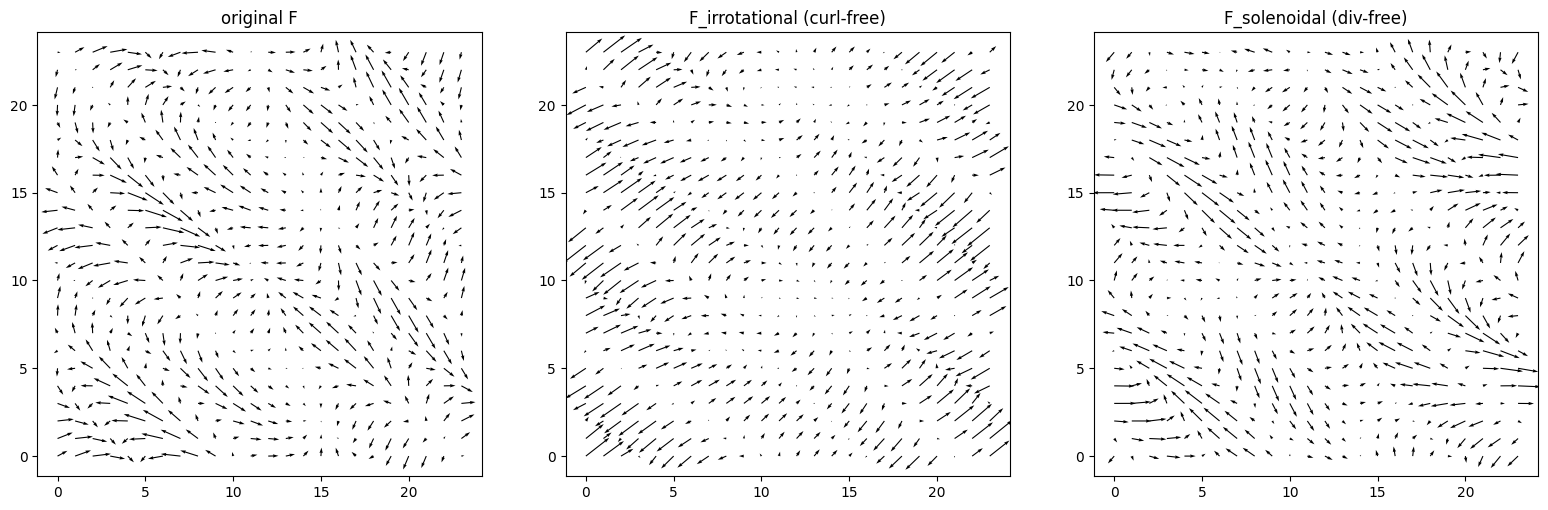

In [6]:
z_idx = N // 2
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
titles = ['original F', 'F_irrotational (curl-free)', 'F_solenoidal (div-free)']
fields = [F, F_irrot, F_sol]
for ax, title, field in zip(axes, titles, fields):
    ax.quiver(field[:, :, z_idx, 0], field[:, :, z_idx, 1])
    ax.set_title(title)
    ax.set_aspect('equal')
plt.tight_layout()
plt.savefig('helmholtz_decomposition_slices.png', dpi=100, bbox_inches='tight')
plt.show()


## 6. Engineering Interpretation

- The exactness in Sections 2-3 (errors at $10^{-14}$-$10^{-9}$, not just
  "small") is a direct consequence of doing calculus in Fourier space on a
  band-limited field -- the SAME reason this repo's dispersion kernel
  $H(f)=e^{i\pi Df^2}$ is applied via FFT multiplication rather than a
  finite-difference PDE solve. Spectral methods aren't just convenient
  here; they remove an entire error source.
- Section 3's two identities (curl of the irrotational part is zero,
  divergence of the solenoidal part is zero) are literally
  `dgs.irrotational_solenoidal_polyglot`'s two theorems, but demonstrated
  on a field that DIDN'T start out obeying either one -- the decomposition
  manufactures fields with those properties out of a generic field that
  has neither.
- The DC-mode convention (Section on `helmholtz_decompose`'s docstring)
  matters for bookkeeping but not for physics: a spatially constant field
  trivially has zero curl AND zero divergence, so which "bucket" it's
  assigned to doesn't change either verified property.


## 7. Research Discussion

- This module's periodic/FFT approach only works for a field defined on a
  periodic domain (or one that can be zero-padded to look periodic); a
  field defined on all of space with sources at isolated points (like
  `dgs.irrotational_solenoidal_polyglot`'s two examples) needs the
  classical Helmholtz theorem's integral form (a convolution with the
  Green's function $1/4\pi r$) instead -- a natural, harder follow-up.
- `dgs.gs_spatial_torch`'s 2-D spatial Gerchberg-Saxton and this module's
  3-D spectral decomposition both split a field's Fourier representation
  by a geometric criterion (amplitude constraint vs. longitudinal/
  transverse projection) -- worth writing up as an explicit "Fourier-space
  projection is how a lot of this repo's algorithms work" pattern note.
- A natural completion of the Griffiths thread this session has followed:
  verify that `dgs.irrotational_solenoidal_polyglot`'s two example fields,
  if sampled onto a periodic grid (with the singularity excluded/smoothed)
  and run through `helmholtz_decompose`, come back out as (almost) purely
  one part or the other -- a numeric confirmation that the "special case"
  fields really do sit at the two extremes this module's generic field
  interpolates between.


## 8. Possible Experiments

1. Vary `n_modes` in `synthetic_test_field` from 1 up to a large number
   and watch how the relative energy split between `F_irrotational` and
   `F_solenoidal` changes -- does a single-mode field always decompose
   into a predictable ratio based on how aligned that mode's direction is
   with its own wavevector?
2. Zero out the DC mode explicitly before decomposing and confirm the
   `k=0` convention noted in Section 6 genuinely doesn't affect the two
   verified properties.
3. Increase `N` (grid resolution) and track how `reconstruction_error`,
   `max|curl(F_irrotational)|`, and `max|div(F_solenoidal)|` scale --
   they should stay near machine epsilon regardless of `N`, unlike a
   finite-difference method's error which would grow with coarser grids.


## 9. Future Improvements

- Add a non-periodic (open-domain) Helmholtz decomposition via the
  classical Green's-function convolution, and cross-check it against this
  module's periodic/FFT method on a field that's smooth and well
  band-limited within a large-enough periodic box (where the two methods
  should agree).
- `torch_verify_decomposition` currently only checks the DECOMPOSITION's
  correctness; extending it to keep the torch tensors differentiable
  (`requires_grad=True` on `synthetic_test_field`'s Fourier coefficients)
  would let a downstream optimization TARGET a specific
  irrotational/solenoidal energy ratio via gradient descent, in the same
  spirit as `dgs.eye_cad_torch`'s constraint solver.
